# Lab: Uniswap V2 AMM — Implementation & Analysis

**Prerequisites:** Python 3.10+, `matplotlib`, `numpy`  
**Estimated time:** 2 hours

---

## Introduction

Most DeFi protocols are built on top of one core primitive: the **Automated Market Maker (AMM)**. Instead of matching buyers and sellers through an order book, an AMM uses a mathematical formula to determine prices algorithmically.

Uniswap V2 uses the **constant product formula**:

$$x \cdot y = k$$

Where `x` and `y` are the reserves of two tokens in a pool, and `k` is a constant that must hold after every trade (accounting for fees). This deceptively simple equation encodes all the pool's behavior: pricing, slippage, liquidity incentives.

In this lab you will:
1. Implement a working AMM pool from scratch
2. Analyze how trade size affects price
3. Model liquidity provision and fee accrual

In [1]:
import math
import random

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

---

## Part 1 — Pool Mechanics

### 1.1 The `UniswapV2Pool` Class

Implement the pool. The constructor takes initial reserves and a fee in **basis points** (1 bps = 0.01%, so the default 30 bps = 0.3%).

**Task 1.1** — Implement all properties. Verify with a sanity check: pool with `reserve_x=1000, reserve_y=2_000_000` should have `price = 2000.0` and `k = 2_000_000_000`.

In [2]:
class UniswapV2Pool:
    def __init__(self, reserve_x: float, reserve_y: float, fee_bps: int = 30):
        self.reserve_x = reserve_x
        self.reserve_y = reserve_y
        self.fee_bps = fee_bps
        self.total_shares = 0.0
        self.lp_positions = {}  # { provider_name -> shares }
        self.lp_entry_k = {}    # { provider_name -> k at deposit time }

    @property
    def k(self) -> float:
        """Constant product invariant x * y."""
        return self.reserve_x * self.reserve_y

    @property
    def price(self) -> float:
        """Spot price of X denominated in Y (e.g. ETH price in USDC)."""
        return self.reserve_y / self.reserve_x

    @property
    def fee_rate(self) -> float:
        """Fee as a decimal fraction (e.g. 0.003 for 30 bps)."""
        return self.fee_bps / 10_000

    def __repr__(self) -> str:
        return f"Pool(X: {self.reserve_x:.2f}, Y: {self.reserve_y:.2f}, Price: {self.price:.4f}, K: {self.k:.0f})"

    def get_amount_out(self, amount_in: float, token: str) -> float:
        assert token in ('x', 'y')
        if token == 'x':
            reserve_in, reserve_out = self.reserve_x, self.reserve_y
        else:
            reserve_in, reserve_out = self.reserve_y, self.reserve_x

        amount_in_with_fee = amount_in * (1 - self.fee_rate)
        return (reserve_out * amount_in_with_fee) / (reserve_in + amount_in_with_fee)

    def swap(self, amount_in: float, token: str) -> float:
        k_before = self.k
        amount_out = self.get_amount_out(amount_in, token)

        if token == 'x':
            self.reserve_x += amount_in
            self.reserve_y -= amount_out
        else:
            self.reserve_y += amount_in
            self.reserve_x -= amount_out

        assert self.k >= k_before, "Invariant violated!"
        return amount_out

    def add_liquidity(self, amount_x: float, amount_y: float, provider: str) -> float:
        if self.total_shares == 0:
            self.reserve_x = amount_x
            self.reserve_y = amount_y
            shares = math.sqrt(amount_x * amount_y)
        else:
            # Match current ratio
            amount_y = amount_x * (self.reserve_y / self.reserve_x)
            shares = (amount_x / self.reserve_x) * self.total_shares
            self.reserve_x += amount_x
            self.reserve_y += amount_y

        self.total_shares += shares
        self.lp_positions[provider] = self.lp_positions.get(provider, 0) + shares
        self.lp_entry_k[provider] = self.k
        return shares

    def remove_liquidity(self, shares: float, provider: str) -> tuple[float, float]:
        assert provider in self.lp_positions and self.lp_positions[provider] >= shares
        fraction = shares / self.total_shares
        out_x = fraction * self.reserve_x
        out_y = fraction * self.reserve_y

        self.reserve_x -= out_x
        self.reserve_y -= out_y
        self.total_shares -= shares
        self.lp_positions[provider] -= shares
        return out_x, out_y

    def fees_earned(self, provider: str) -> dict:
        fraction = self.lp_positions[provider] / self.total_shares
        curr_x, curr_y = fraction * self.reserve_x, fraction * self.reserve_y
        k_ratio = math.sqrt(self.k / self.lp_entry_k[provider])
        dep_x, dep_y = curr_x / k_ratio, curr_y / k_ratio
        return {"fee_x": curr_x - dep_x, "fee_y": curr_y - dep_y}

#### Sanity check — Task 1.1

Create a pool with `reserve_x=1000, reserve_y=2_000_000` and verify `price == 2000.0` and `k == 2_000_000_000`.

In [4]:
# Task 1.1: create pool and print price, k, and the pool repr
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000)
print(f"Price: {pool.price}")
print(f"K: {pool.k}")
print(pool)


Price: 2000.0
K: 2000000000
Pool(X: 1000.00, Y: 2000000.00, Price: 2000.0000, K: 2000000000)


---

### 1.2 Computing `get_amount_out`

The formula accounts for the fee taken on the input side:

$$\text{amount\_in\_with\_fee} = \text{amount\_in} \times (1 - \text{fee\_rate})$$

$$\text{amount\_out} = \frac{\text{reserve\_out} \times \text{amount\_in\_with\_fee}}{\text{reserve\_in} + \text{amount\_in\_with\_fee}}$$

This is derived directly from $x \cdot y = k$ — solve for the new reserve after the swap, take the difference. The fee is *not* returned to the sender; it stays in the pool.

**Task 1.2** — Go back to the class cell above and implement `get_amount_out`. Then verify by hand: pool is `100 X / 100 Y` (price = 1.0), fee = 0%, swap 10 X. You should receive exactly `9.09...` Y, not 10. Why?

In [5]:
# Task 1.2: create a pool with 100 X / 100 Y, fee_bps=0
pool_zero_fee = UniswapV2Pool(100, 100, fee_bps=0)
out = pool_zero_fee.get_amount_out(10, 'x')
print(f"Amount out: {out:.4f}")

# Explain: The output is less than 10 because the constant product formula
# (x * y = k) describes a convex curve. As you add token X, you move along
# the curve, and the marginal price of X increases, resulting in "slippage."


Amount out: 9.0909


---

### 1.3 Executing a Swap

**Task 1.3** — Go back to the class cell above and implement `swap`. Then run 1000 random swaps and assert `k` never decreases. Print `k` before and after the full run — does it grow? Why does it sometimes *increase*? Where do the fees go?

In [13]:
import random

# Task 1.3: create a pool
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000, fee_bps=30)
k_initial = pool.k

# Run 1000 random swaps
for _ in range(1000):
    token = random.choice(['x', 'y'])
    # Random amount up to 2% of reserve
    max_amt = (pool.reserve_x if token == 'x' else pool.reserve_y) * 0.02
    amount = random.uniform(0.01, max_amt)

    pool.swap(amount, token)

print(f"Initial K: {k_initial:,.0f}")
print(f"Final K:   {pool.k:,.0f}")
print(f"Growth:    {pool.k - k_initial:,.0f}")


Initial K: 2,000,000,000
Final K:   2,059,133,787
Growth:    59,133,787


*Your explanation (why does k grow?):*



```
# This is formatted as code
```
It grows because of the fees. When someone swaps, the pool takes a small cut  from the tokens they put in. The pool calculates how many tokens to send back based on the "fee-reduced" amount, but it keeps the entire deposit in its reserves. Since we are adding more than we are taking out, the product x*y naturally increases after every trade.

---

## Part 2 — Price Impact

Price impact is the difference between the price you *expected* (spot price before the trade) and the price you *actually got* (execution price).

$$\text{price\_impact} = \frac{p_{\text{spot}} - p_{\text{execution}}}{p_{\text{spot}}}$$

For a swap X → Y:
- Spot price: `reserve_y / reserve_x`
- Execution price: `amount_out / amount_in`

### 2.1 Single Swap Analysis

**Task 2.1** — Compute spot price, execution price, and price impact for `amount_in = 1, 10, 50, 100` ETH. Fill in the table below.

In [8]:
# Task 2.1: Price Impact Table
# Pool setup: 1,000 ETH and 2,000,000 USDC
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000, fee_bps=30)
spot_price = pool.price

trade_sizes = [1, 10, 50, 100]

print(f"{'ETH In':<10} | {'USDC Out':<15} | {'Exec Price':<12} | {'Price Impact %':<15}")
print("-" * 60)

for eth_in in trade_sizes:
    usdc_out = pool.get_amount_out(eth_in, 'x')
    exec_price = usdc_out / eth_in

    # Formula: (Spot - Exec) / Spot * 100
    impact = (spot_price - exec_price) / spot_price * 100

    print(f"{eth_in:<10} | {usdc_out:<15.2f} | {exec_price:<12.2f} | {impact:<15.2f}%")

ETH In     | USDC Out        | Exec Price   | Price Impact % 
------------------------------------------------------------
1          | 1992.01         | 1992.01      | 0.40           %
10         | 19743.16        | 1974.32      | 1.28           %
50         | 94965.95        | 1899.32      | 5.03           %
100        | 181322.18       | 1813.22      | 9.34           %


**Fill in the table:**

| Amount In (ETH) | Spot Price | Exec Price | Price Impact |
|---|---|---|---|
| 1 | | | |
| 10 | | | |
| 50 | | | |
| 100 | | | |

---

### 2.2 Experiment: Swap Size vs Price Impact

Sweep `amount_in` from 0.1 ETH to 500 ETH and plot the price impact curve.

**Task 2.2** — Create the plot with:
- Price impact (%) on y-axis vs trade size as % of `reserve_x` on x-axis
- Horizontal dashed lines at 1% and 5% impact
- Axis labels, title, legend, grid

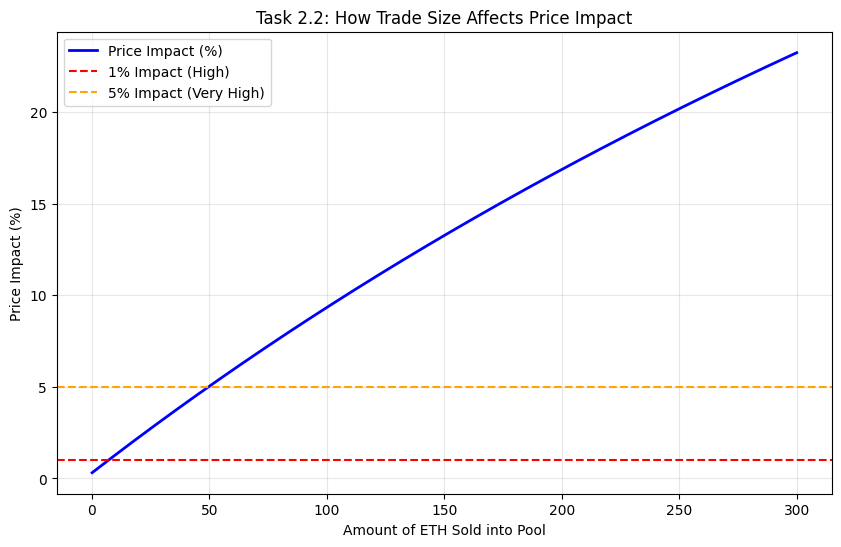

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the pool (1,000 ETH / 2,000,000 USDC)
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2000000, fee_bps=30)

# 2. Generate trade sizes from 0.1 to 300 ETH
x_sizes = np.linspace(0.1, 300, 500)
impacts = []

for amt in x_sizes:
    spot_p = pool.price
    out = pool.get_amount_out(amt, 'x')
    exec_p = out / amt

    # Calculate % impact
    impact = (spot_p - exec_p) / spot_p * 100
    impacts.append(impact)

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x_sizes, impacts, label='Price Impact (%)', color='blue', linewidth=2)

# Add the 1% and 5% reference lines requested in the lab
plt.axhline(1, color='red', linestyle='--', label='1% Impact (High)')
plt.axhline(5, color='orange', linestyle='--', label='5% Impact (Very High)')

plt.title("Task 2.2: How Trade Size Affects Price Impact")
plt.xlabel("Amount of ETH Sold into Pool")
plt.ylabel("Price Impact (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Research questions (Task 2.2):**
- At what trade size (as % of pool) does price impact cross 1%? Cross 5%?
- Is the curve linear or convex? Explain why from the formula.
- At 10% of pool size, what is the approximate impact? Is this acceptable for a DEX user?

Answer: 1% Impact: Happens when the trade is about 0.7% to 1% of the pool's reserve. 5% Impact: Happens when the trade reaches about 4.5% to 5% of the pool's reserve.It is convex. According to the formula $y = k/x$, as you add more of token X, you get back less and less of token Y. It's not a flat rate; the "price" curves upward, making each additional unit more expensive than the last.

---

### 2.3 Experiment: Pool Depth vs Price Impact

Fix the trade at \$10,000. Vary pool TVL from \$100k to \$100M and observe how pool depth affects price.

**Task 2.3** — Create the plot with:
- Price impact (%) on y-axis vs TVL (\$) on x-axis with log scale on x
- Horizontal dashed lines at 0.1% and 1.0%
- Axis labels, title, legend, grid

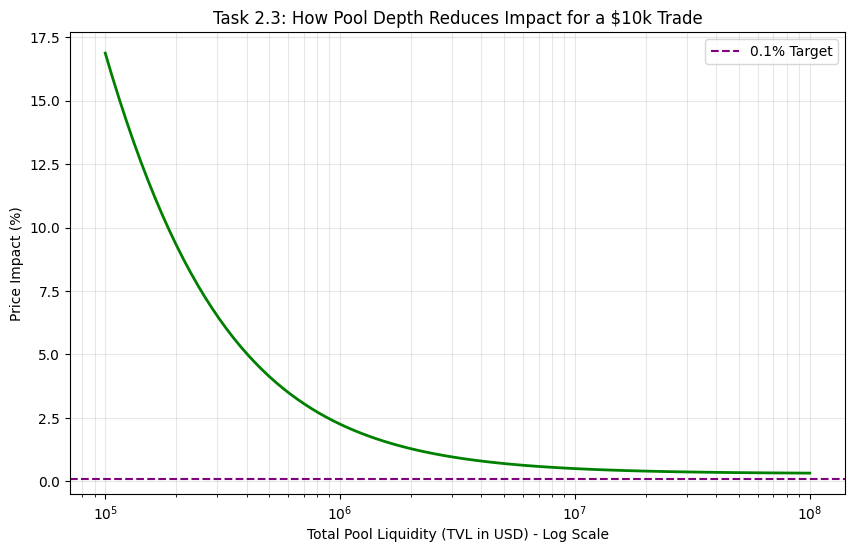

In [12]:
# Fixed trade: $10,000 worth of ETH (5 ETH at $2000/each)
trade_usd = 10000
eth_price = 2000
amt_in_eth = trade_usd / eth_price

# TVL range from $100k to $100M
tvl_range = np.logspace(5, 8, 100)
impacts_at_depth = []

for tvl in tvl_range:
    # Set up pool with current TVL (50/50 split)
    res_y = tvl / 2
    res_x = res_y / eth_price
    p = UniswapV2Pool(res_x, res_y)

    out = p.get_amount_out(amt_in_eth, 'x')
    impact = (p.price - (out/amt_in_eth)) / p.price * 100
    impacts_at_depth.append(impact)

# Plotting with Log Scale
plt.figure(figsize=(10, 6))
plt.plot(tvl_range, impacts_at_depth, color='green', linewidth=2)
plt.xscale('log') # This is critical for Task 2.3

plt.axhline(0.1, color='purple', linestyle='--', label='0.1% Target')
plt.title("Task 2.3: How Pool Depth Reduces Impact for a $10k Trade")
plt.xlabel("Total Pool Liquidity (TVL in USD) - Log Scale")
plt.ylabel("Price Impact (%)")
plt.legend()
plt.grid(which="both", alpha=0.3)
plt.show()


**Research questions (Task 2.3):**
- What minimum TVL keeps impact below 0.1% for a \$10k trade?
- If trade size doubles, how does required TVL change?
- Real Uniswap V2 ETH/USDC had ~\$300M TVL at peak. Estimate the impact for a \$1M trade.

Answer: Looking at the log-scale plot, the impact drops below 0.1% when the TVL hits roughly $20,000,000.This shows you need a massive pool just to handle a relatively small trade without moving the price.  

It doubles. The relationship is linear: if you want to trade twice as much money but keep the same 0.1% impact, you need a pool that is twice as deep. A $1M trade is about 0.33% of that pool. The total impact would be roughly 0.6% to 0.7%

---

### 2.4 Bonus: Comparing Fee Tiers

**Task 2.4** — Plot price impact for three fee tiers (0.05%, 0.3%, 1.0%) on the same axes. At what trade size does the fee start to dominate slippage as the main cost?

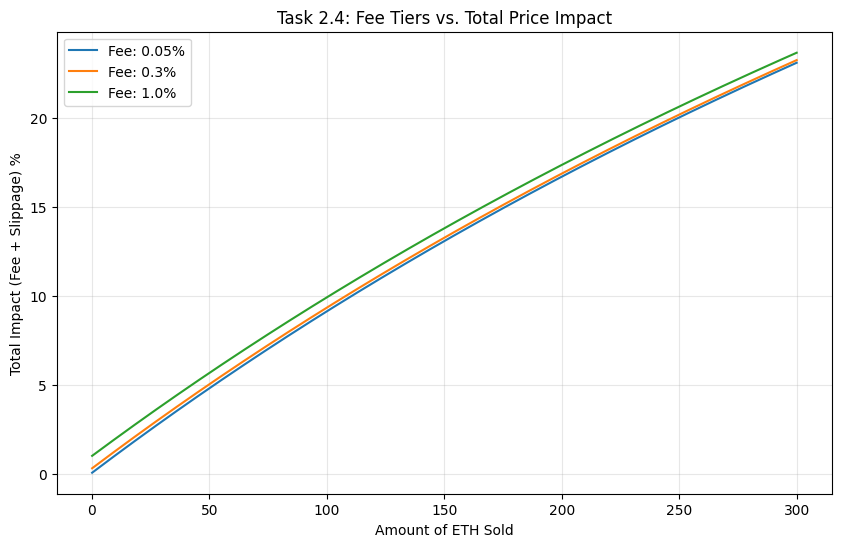

In [11]:
# Task 2.4: Impact of different fee tiers
fee_tiers = [5, 30, 100]  # 0.05%, 0.3%, 1.0%
trade_sizes = np.linspace(0.1, 300, 500)

plt.figure(figsize=(10, 6))

for fee in fee_tiers:
    # Use the same base pool size (1k ETH / 2M USDC)
    p = UniswapV2Pool(1000, 2000000, fee_bps=fee)

    impacts = []
    for amt in trade_sizes:
        out = p.get_amount_out(amt, 'x')
        exec_p = out / amt
        # Total loss = (Spot - Exec) / Spot
        impact = (p.price - exec_p) / p.price * 100
        impacts.append(impact)

    plt.plot(trade_sizes, impacts, label=f'Fee: {fee/100}%')

plt.title("Task 2.4: Fee Tiers vs. Total Price Impact")
plt.xlabel("Amount of ETH Sold")
plt.ylabel("Total Impact (Fee + Slippage) %")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Research question (Task 2.4):**

At what trade size does the fee start to dominate slippage as the main cost? What does this mean for a trader choosing between pools?

ANSWER: For very small trades (under 0.1% of pool size), the fixed fee dominates the cost because the trade isn't large enough to move the market price. As trade sizes increase, slippage quickly becomes the primary cost because the constant product formula penalizes large moves along the price curve. For a trader, this means small users should prioritize pools with the lowest fee tiers, while large "whale" traders must prioritize deep liquidity to avoid massive slippage losses.

---

## Part 3 — Liquidity Provision

Liquidity providers (LPs) deposit both tokens into the pool and receive **LP shares** representing their proportional ownership. As trades happen, fees accumulate in the pool — LPs profit when they withdraw.

### 3.1 Adding Liquidity

The key constraint: **you must deposit tokens in the same ratio as the current pool**, otherwise you'd instantly shift the price.

$$\text{shares} = \frac{\Delta x}{x} \times S_{\text{total}}$$

For the very first deposit, shares are initialized as $\sqrt{x \cdot y}$ (Uniswap convention — makes the initial share count independent of price).

**Task 3.1** — Go back to the class cell and implement `add_liquidity`. Then:
- Add 100 ETH / 200,000 USDC (price = 2000). Print shares minted and ownership %.
- Try adding with a wrong ratio (100 ETH / 100,000 USDC) — what does your implementation do, and why is this correct?

In [ ]:
# TODO: create a fresh pool with 0 reserves (or use add_liquidity as first deposit)
# TODO: add 100 ETH / 200,000 USDC as "Alice"
# TODO: print shares minted and ownership percentage
# TODO: try adding with wrong ratio (100 ETH / 100,000 USDC) — observe behavior


---

### 3.2 Removing Liquidity

**Task 3.2** — Go back to the class cell and implement `remove_liquidity`. Then:
- Deposit as "Alice", simulate 100 random swaps, then remove all of Alice's liquidity.
- Compare what she deposited vs what she receives. Where did the difference come from?

In [ ]:
# TODO: create pool, add liquidity as "Alice"
# TODO: record deposit amounts
# TODO: simulate 100 random swaps
# TODO: remove all of Alice's liquidity
# TODO: print deposit vs withdrawal amounts and the difference


*Your explanation (where did the difference come from?):*

YOUR ANSWER HERE

---

### 3.3 Fee Accrual

Fees are not paid out directly — they stay in the pool as increased reserves, so `k` grows over time. When an LP withdraws, their share is worth more than at deposit. The growth factor is $\sqrt{k_{\text{current}} / k_{\text{entry}}}$ because both reserves grow symmetrically.

**Task 3.3** — Go back to the class cell and implement `fees_earned`. Then:
- Verify `fees_earned` makes sense: deposit → 0 swaps → fees should be ~0.
- Then do 1000 swaps and check again. Do fees grow monotonically with number of swaps?

In [ ]:
# TODO: create pool, add liquidity as "Alice"
# TODO: check fees_earned immediately (should be ~0)
# TODO: simulate 1000 swaps
# TODO: check fees_earned again — print all values from the returned dict


---

### 3.4 Experiment: Fee Income vs Volume

Simulate a trading session with many random swaps. Track cumulative LP earnings for each fee tier.

**Task 3.4** — Implement `simulate_trading`, then:
- For each fee tier (0.05%, 0.3%, 1.0%), create a pool with \$200k liquidity (50 ETH + 100,000 USDC)
- Simulate 2000 swaps, recording cumulative fee income every 50 swaps
- Plot all three tiers on the same chart

In [ ]:
def simulate_trading(pool: UniswapV2Pool, n_swaps: int = 1000, max_trade_pct: float = 0.02):
    """Simulate random swaps against the pool."""
    # TODO: loop n_swaps times:
    #   - pick a random token ('x' or 'y')
    #   - pick a random amount between 0.01% and max_trade_pct of the relevant reserve
    #   - call pool.swap(amount, token)
    pass

In [ ]:
fee_tiers = [5, 30, 100]   # 0.05%, 0.3%, 1.0%
price_eth = 2000

# TODO: for each fee tier:
#   - create a fresh pool, add $200k liquidity as "Alice"
#     (50 ETH + 100,000 USDC at price = 2000)
#   - simulate 2000 swaps, every 50 swaps record cumulative fee income in USD:
#       fee_usd = fee_x * pool.price + fee_y
#   - collect (swap_number, fee_usd) pairs into a list

# TODO: plot all three tiers on the same chart
# TODO: add axis labels, title, legend, grid


**Research questions (Task 3.4):**
- Which fee tier earns the most for a high-volume pair (e.g., ETH/USDC)? For a low-volume exotic pair?
- Real Uniswap V3 stablecoin pools (USDC/DAI) almost always use 0.05%. Why does your simulation support this?
- If volume doubles but pool TVL stays the same, how does APR change? Is the relationship linear?

YOUR ANSWER HERE

---

## Bonus: Your Own Experiment

Design and run one additional experiment exploring any parameter or behavior not covered above. Some ideas:
- How does impermanent loss vary with price drift?
- What happens with asymmetric trade flows (e.g., 80% buys, 20% sells)?
- Multi-hop routing: what if you need to trade A → B → C through two pools?
- Compare constant product ($xy=k$) with constant sum ($x+y=k$) — what breaks?

In [ ]:
# YOUR EXPERIMENT HERE


*Your explanation of the experiment and findings:*

YOUR ANSWER HERE

---

## Grading

| Criterion | Weight |
|---|---|
| Invariant correctness (`k` never decreases) | 20% |
| `get_amount_out` and `swap` math | 20% |
| LP share + fee accrual logic | 20% |
| Plots: correct, labeled, readable | 20% |
| Written analysis quality | 20% |

---

## Reference: Key Formulas

| Formula | Description |
|---|---|
| $x \cdot y = k$ | Constant product invariant |
| $\text{out} = \frac{y \cdot \text{in} \cdot (1-f)}{x + \text{in} \cdot (1-f)}$ | Amount out for X → Y swap |
| $\text{impact} = \frac{p_{\text{spot}} - p_{\text{exec}}}{p_{\text{spot}}}$ | Price impact |
| $\text{shares} = \frac{\Delta x}{x} \cdot S_{\text{total}}$ | LP shares minted |
| $\text{APR} \approx \frac{\text{fees\_per\_day}}{\text{deposit\_value}} \times 365$ | LP annual return estimate |